In [1]:
import pandas as pd
import seaborn as sns
import os
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
import sklearn as sk # for machine learning
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score


path=r"D:\\ML-SVM\\Housing.csv"

df=pd.read_csv(path)

print(df.head(), "\n")          
# print(df.shape, "\n")           
# print(df.info(), "\n")          
print(df.isnull().sum(), "\n")  
print(df.isna().sum(), "\n")  
# print(df.describe(), "\n")       
# print(df.columns, "\n") 

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished   

price               0
area                0
bedrooms            0
bathrooms           0
stories  

In [2]:
for col in df.columns:
    if df[col].isnull().any():  
        print(f"{col}: {df[col].isnull().sum()}") 
        
        
        
        
for col in df.columns:
    if df[col].dtype == 'object':
       print(f"{col}: {df[col].dtype}")
       
       
       
       


mainroad: object
guestroom: object
basement: object
hotwaterheating: object
airconditioning: object
prefarea: object
furnishingstatus: object


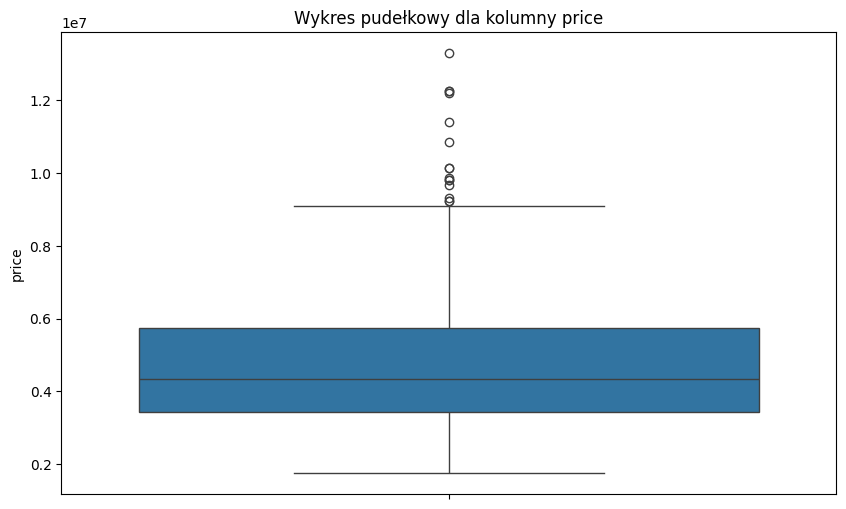

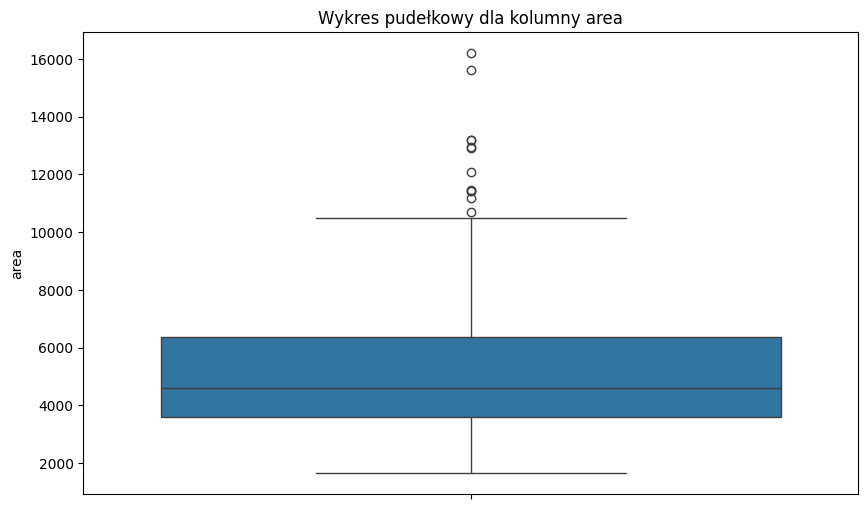

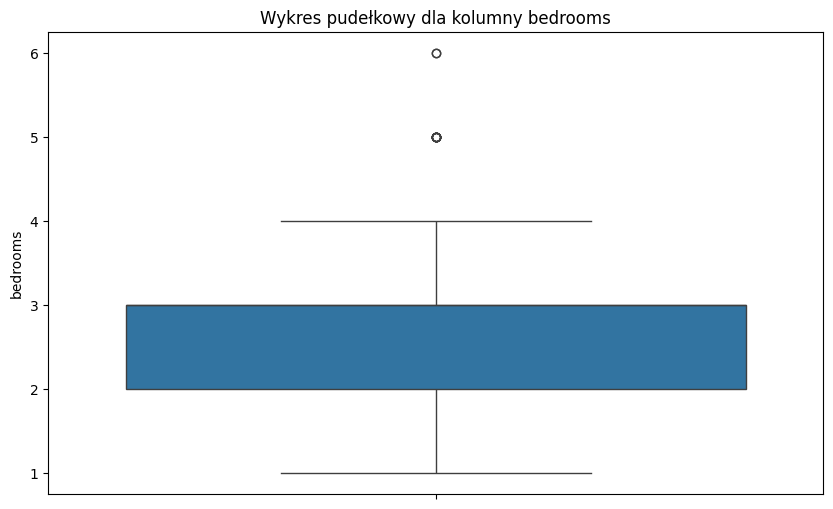

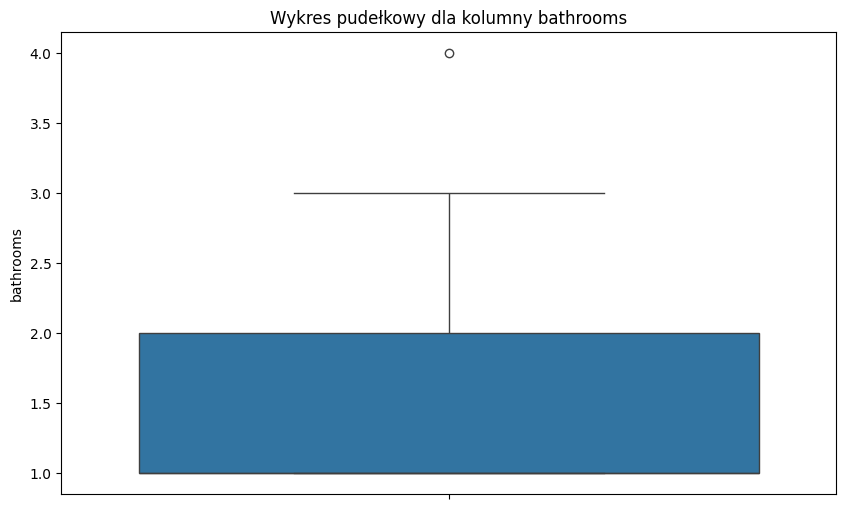

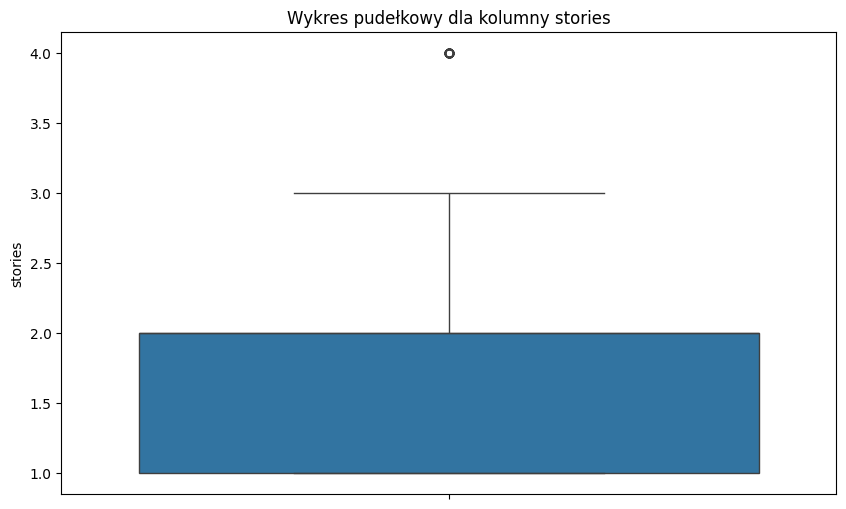

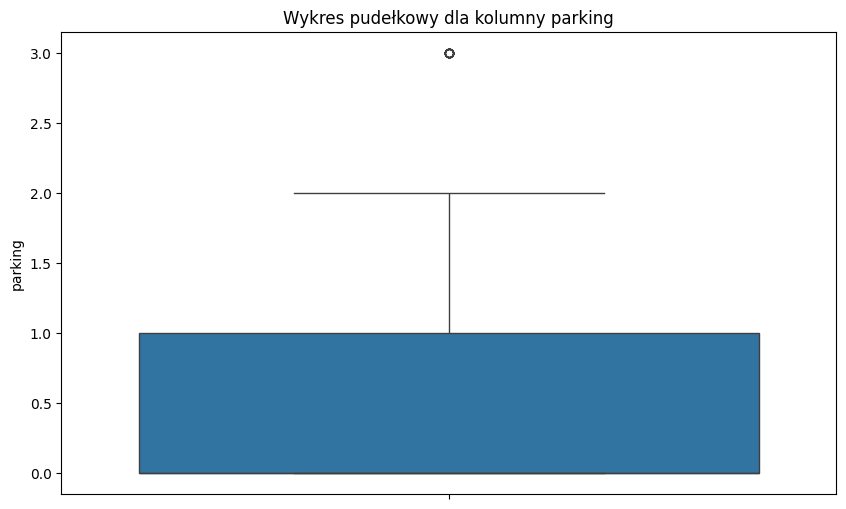

In [3]:
for kolumna in df.select_dtypes(exclude='object').columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df[kolumna])  # Zmień 'kolumna' na nazwę swojej kolumny
    plt.title(f'Wykres pudełkowy dla kolumny {kolumna}')
    plt.show()

In [4]:
from sklearn.preprocessing import OneHotEncoder

print(df.shape)

col=[]

for c in df.columns:
    if df[c].dtype == 'object':  # Check the data type of the column
        print(c)  # Print the column name
        col.append(c)
        
        
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([df, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)
print(f"Encoded House data : \n{df_encoded}")



print(df_encoded.shape)



(545, 13)
mainroad
guestroom
basement
hotwaterheating
airconditioning
prefarea
furnishingstatus
Encoded House data : 
        price  area  bedrooms  bathrooms  stories  parking  mainroad_no  \
0    13300000  7420         4          2        3        2          0.0   
1    12250000  8960         4          4        4        3          0.0   
2    12250000  9960         3          2        2        2          0.0   
3    12215000  7500         4          2        2        3          0.0   
4    11410000  7420         4          1        2        2          0.0   
..        ...   ...       ...        ...      ...      ...          ...   
540   1820000  3000         2          1        1        2          0.0   
541   1767150  2400         3          1        1        0          1.0   
542   1750000  3620         2          1        1        0          0.0   
543   1750000  2910         3          1        1        0          1.0   
544   1750000  3850         3          1        2        

In [5]:
# create dataset
X=df_encoded.drop('price',axis=1)
y=df_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(436, 20)
(109, 20)
(436,)
(109,)


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.svm import SVR


param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__gamma': [0.001, 0.01, 0.1, 1],
    'svr__kernel': ['linear', 'rbf'],
    'svr__epsilon': [0.1, 0.2, 0.5]  # Example of adding epsilon
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

grid = GridSearchCV(pipeline, param_grid, cv=15, scoring='neg_root_mean_squared_error')




grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = root_mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)
# Wyświetlanie wyników
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R² Score: {r2:.2f}')

results = pd.DataFrame({
    'Test': y_test,
    'Predictions': y_pred,
    'Result': y_test - y_pred
})
results['Test'] = results['Test'].astype(float)
results['Predictions'] = results['Predictions'].astype(float)
results['Result'] = results['Result'].astype(float)
# Set display options to show all rows
pd.set_option('display.max_rows', None)  # None means show all rows
pd.set_option('display.float_format', '{:.2f}'.format)  # Format floats to 2 decimal places
# Display the DataFrame
print(results)


Mean Absolute Error (MAE): 1686681.66
Mean Squared Error (MSE): 2265211.04
R² Score: -0.02
           Test  Predictions      Result
316  4060000.00   4296060.19  -236060.19
77   6650000.00   4481676.42  2168323.58
360  3710000.00   4248176.03  -538176.03
90   6440000.00   4362744.60  2077255.40
493  2800000.00   4267080.53 -1467080.53
209  4900000.00   4253372.93   646627.07
176  5250000.00   4408895.02   841104.98
249  4543000.00   4507210.40    35789.60
516  2450000.00   4215652.82 -1765652.82
426  3353000.00   4186327.55  -833327.55
6   10150000.00   4587013.25  5562986.75
497  2660000.00   4210235.89 -1550235.89
422  3360000.00   4212633.14  -852633.14
424  3360000.00   4246192.59  -886192.59
529  2275000.00   4286325.57 -2011325.57
499  2660000.00   4300380.85 -1640380.85
498  2660000.00   4244308.17 -1584308.17
55   7350000.00   4347993.67  3002006.33
476  2940000.00   4316818.34 -1376818.34
486  2870000.00   4266670.81 -1396670.81
72   6720000.00   4412556.01  2307443.99
163  54